In [ ]:
!pip install kagglehub
!pip install kaggle
!pip install scikit-learn
!pip install tensorflow
!pip install opencv-python
!pip install matplotlib

##Importando Dataset do Kaggle

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshaymiddha/crack-segmentation-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/crack-segmentation-dataset


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

dir_baseline = '/kaggle/input/crack-segmentation-dataset/crack_segmentation_dataset'

#Acesso aos diretórios e associação dos diretórios com os vetores
#contendo cada imagem
dir_train = os.path.join(dir_baseline, 'train', 'images')
dir_train_mask = os.path.join(dir_baseline, 'train', 'masks')
dir_test = os.path.join(dir_baseline, 'test', 'images')
dir_test_mask = os.path.join(dir_baseline, 'test', 'masks')

print("Path to train: ", dir_train)
print("Path to train mask: ", dir_train_mask)
print("Path to test: ", dir_test)
print("Path to test mask: ", dir_test_mask)

train_images = sorted(glob(os.path.join(dir_train, "*.jpg")))
test_images  = sorted(glob(os.path.join(dir_test, "*.jpg")))
train_masks  = sorted(glob(os.path.join(dir_train_mask, "*.jpg")))
test_masks   = sorted(glob(os.path.join(dir_test_mask, "*.jpg")))

print("Train size:", len(train_images))
print("Test size :", len(test_images))

Path to train:  /kaggle/input/crack-segmentation-dataset/crack_segmentation_dataset/train/images
Path to train mask:  /kaggle/input/crack-segmentation-dataset/crack_segmentation_dataset/train/masks
Path to test:  /kaggle/input/crack-segmentation-dataset/crack_segmentation_dataset/test/images
Path to test mask:  /kaggle/input/crack-segmentation-dataset/crack_segmentation_dataset/test/masks
Train size: 9603
Test size : 1695


##Verificação de imagens do dataset

In [ ]:
IMG_SIZE = (128, 128)

def preprocess(img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.resize(img, IMG_SIZE)
    img = img / 255.0

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, IMG_SIZE)
    mask = mask / 255.0
    mask = np.expand_dims(mask, axis=-1)

    return img, mask

X, y = zip(*[preprocess(i, m) for i, m in zip(train_images, train_masks)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape  :", X_val.shape, y_val.shape)

Train shape: (7682, 128, 128, 3) (7682, 128, 128, 1)
Val shape  : (1921, 128, 128, 3) (1921, 128, 128, 1)


##Funções para treino do modelo

Modelo à ser treinado é uma rede neural específica para segmentação de imagens com rachaduras.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

def buildModel(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    skips = []
    x = inputs
    for filters in [32, 64, 128]:
        x = conv_block(x, filters)
        skips.append(x)
        x = layers.MaxPooling2D()(x)

    # Bottleneck
    x = conv_block(x, 64)

    # Decoder
    for filters, skip in zip([128, 64, 32], reversed(skips)):
        x = layers.UpSampling2D()(x)
        x = layers.Concatenate()([x, skip])
        x = conv_block(x, filters)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model


def dice_loss(y_true, y_pred, smooth=1.0):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f)

    return 1.0 - (2.0 * intersection + smooth) / (union + smooth)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    d_loss = dice_loss(y_true, y_pred)
    return bce + d_loss


##Treino do modelo

In [ ]:
model = buildModel()
model.compile(optimizer='adam',loss=bce_dice_loss, metrics=['accuracy'])

#Definição de callback para parada do treino caso não haja mudança na acurácia
#Do modelo em até 3 epochs

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True)
]

history = model.fit(X_train, y_train,validation_data=(X_val, y_val),epochs=10,batch_size=16,)

Epoch 1/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 65s 97ms/step - accuracy: 0.9450 - loss: 0.9840 - val_accuracy: 0.9373 - val_loss: 0.6999
Epoch 2/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 52s 65ms/step - accuracy: 0.9513 - loss: 0.6271 - val_accuracy: 0.9485 - val_loss: 0.5746
Epoch 3/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - accuracy: 0.9557 - loss: 0.5311 - val_accuracy: 0.9576 - val_loss: 0.5230
Epoch 4/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.9573 - loss: 0.5035 - val_accuracy: 0.9540 - val_loss: 0.5002
Epoch 5/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - accuracy: 0.9570 - loss: 0.4872 - val_accuracy: 0.9561 - val_loss: 0.4877
Epoch 6/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - accuracy: 0.9590 - loss: 0.4674 - val_accuracy: 0.9555 - val_loss: 0.4838
Epoch 7/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.9594 - loss: 0.4490 - val_accuracy: 0.9580 - val_loss: 0.4590
Epoch 8/10
481/481 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.9596 - loss: 0.4418 - 

In [ ]:
  def dice_coef(y_true, y_pred, smooth=1e-7):
      y_true = y_true.astype(np.float32).ravel()
      y_pred = y_pred.astype(np.float32).ravel()

      intersection = np.dot(y_true, y_pred)
      total = y_true.sum() + y_pred.sum()
      return (2. * intersection + smooth) / (total + smooth)

  def iou_score(y_true, y_pred, threshold=0.5, smooth=1e-7):
      y_true = y_true.astype(np.bool_).ravel()
      y_pred = (y_pred > threshold).astype(np.bool_).ravel()

      intersection = np.logical_and(y_true, y_pred).sum()
      union = np.logical_or(y_true, y_pred).sum()
      return (intersection + smooth) / (union + smooth)

  # Predição
  y_val_pred = model.predict(X_val)

  # Métricas das primeiras 10 máscaras
  for i in range(10):
      d = dice_coef(y_val[i], y_val_pred[i])
      iou = iou_score(y_val[i], y_val_pred[i])
      print(f"Sample {i}: Dice = {d:.4f} | IoU = {iou:.4f}")

61/61 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step
Sample 0: Dice = 0.1398 | IoU = 0.0988
Sample 1: Dice = 0.0000 | IoU = 0.0000
Sample 2: Dice = 0.5602 | IoU = 0.3263
Sample 3: Dice = 0.6688 | IoU = 0.6042
Sample 4: Dice = 0.6759 | IoU = 0.6616
Sample 5: Dice = 0.0000 | IoU = 1.0000
Sample 6: Dice = 0.5322 | IoU = 0.3827
Sample 7: Dice = 0.6137 | IoU = 0.4350
Sample 8: Dice = 0.0042 | IoU = 0.0000
Sample 9: Dice = 0.0000 | IoU = 0.0000


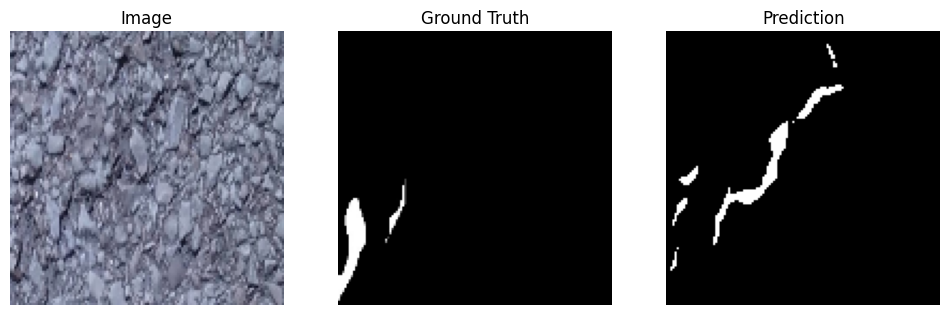

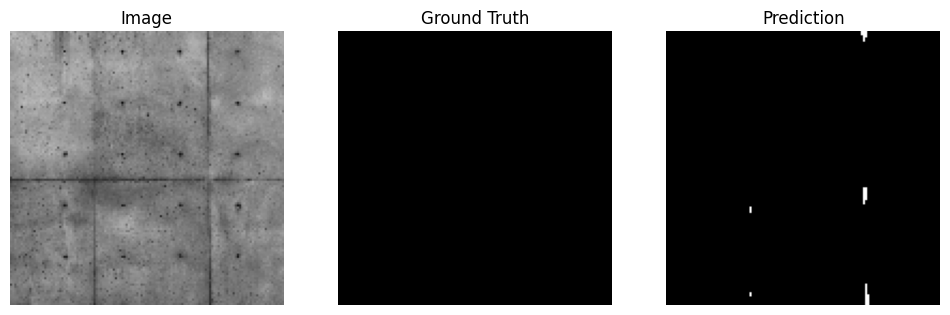

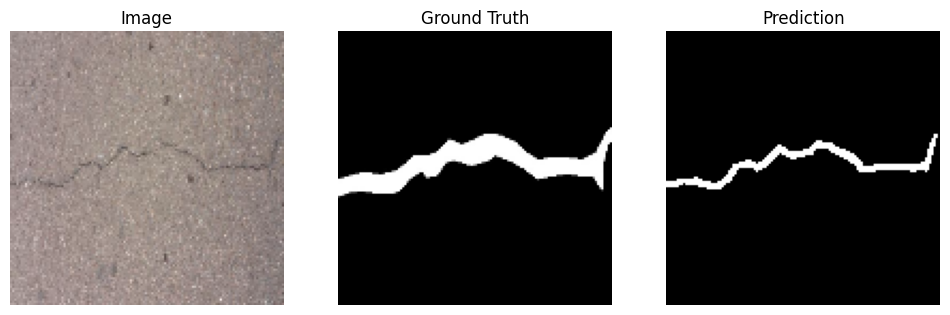

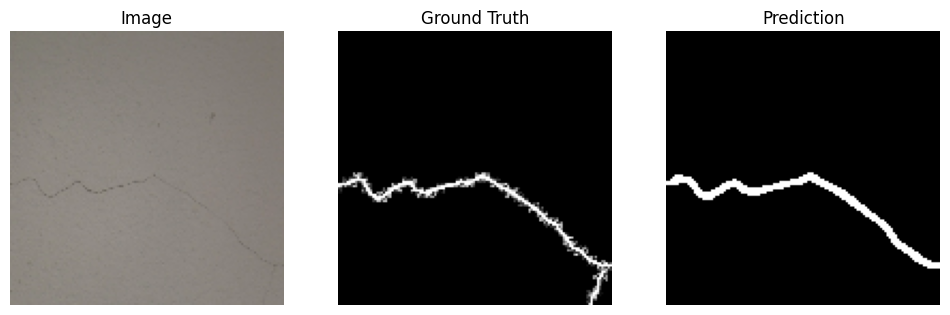

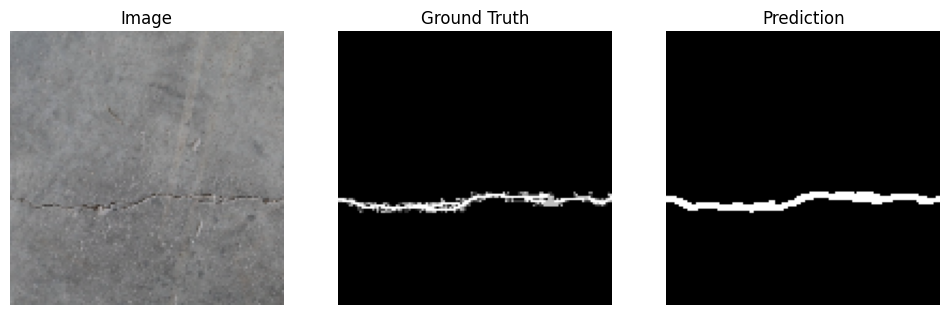

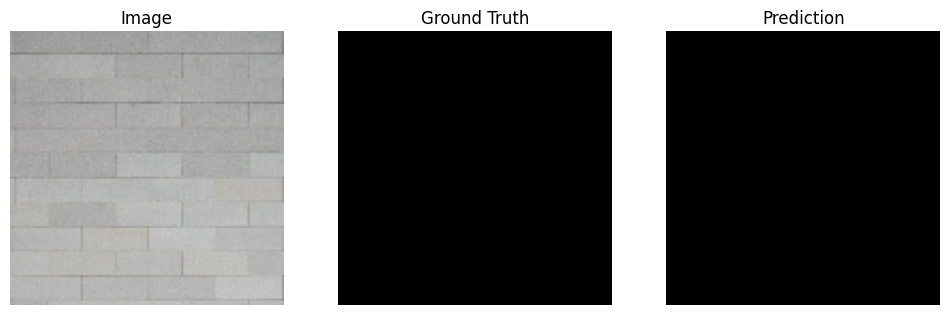

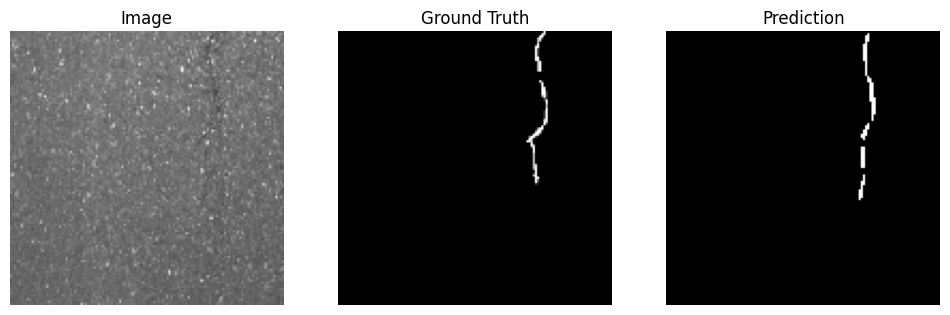

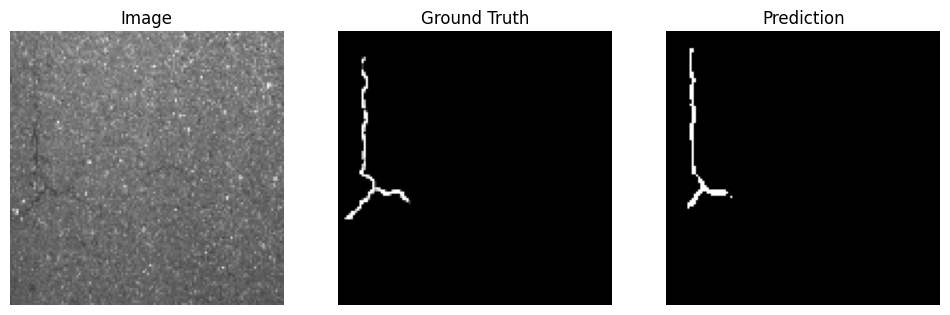

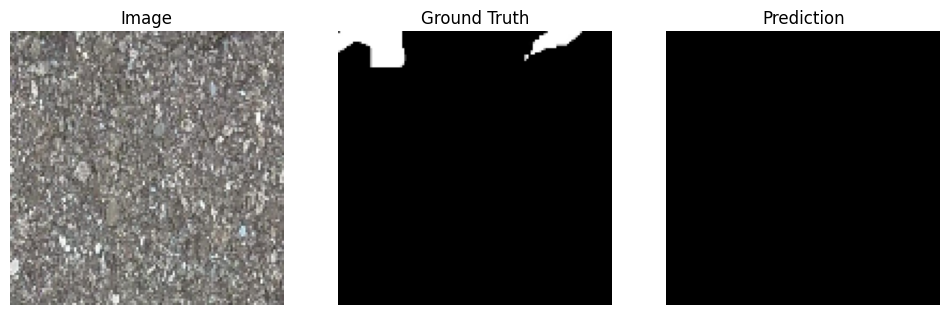

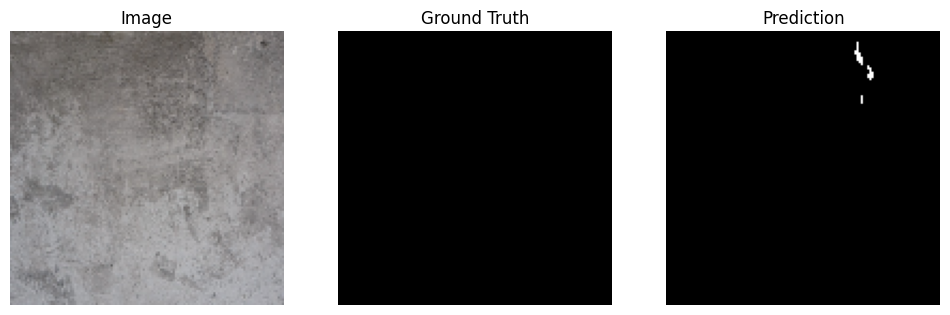

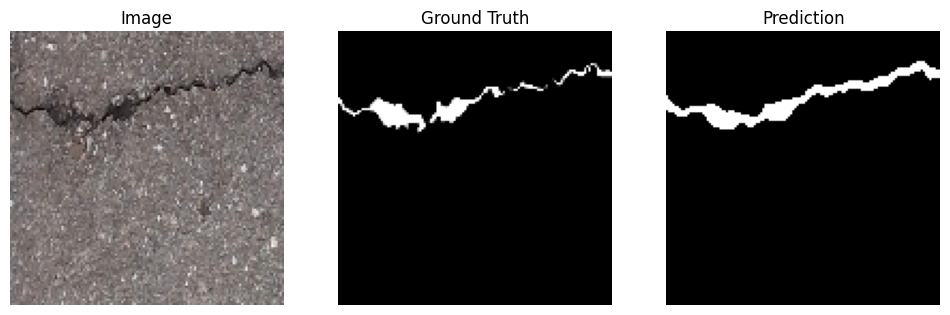

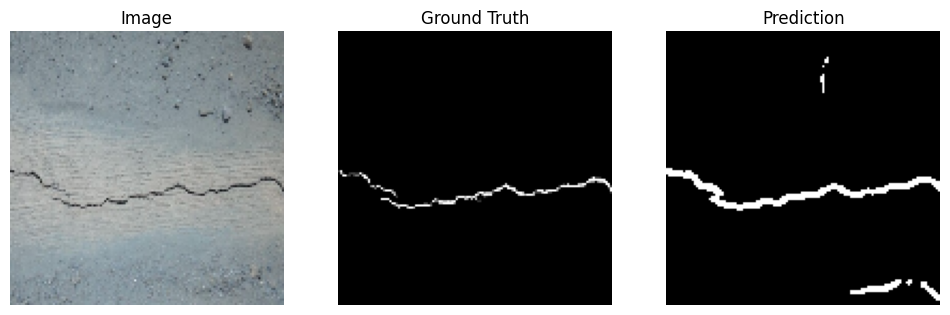

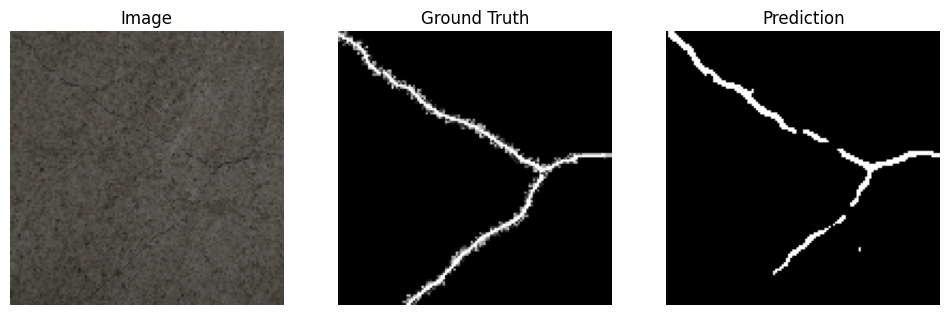

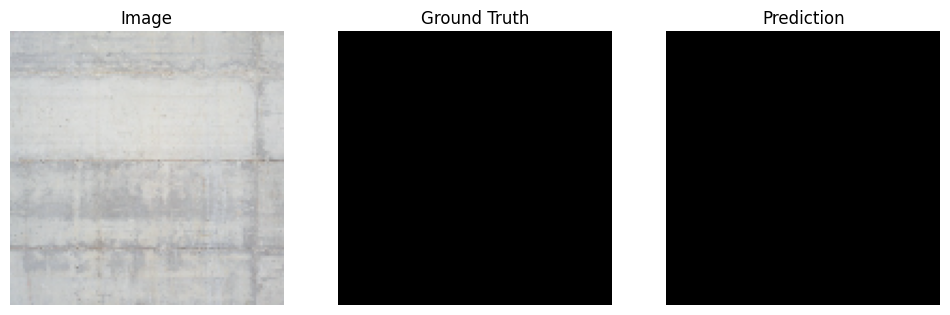

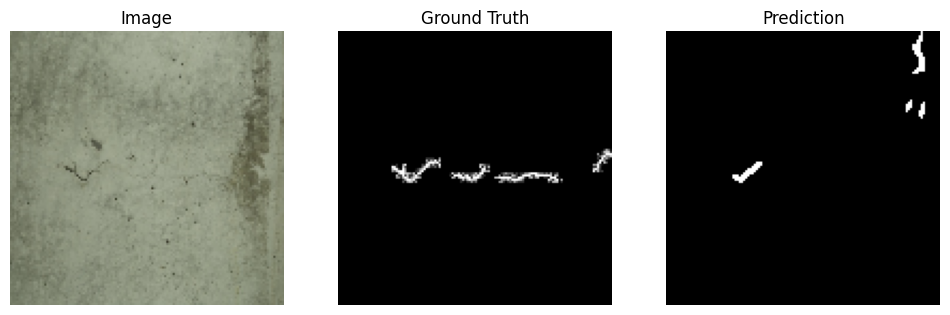

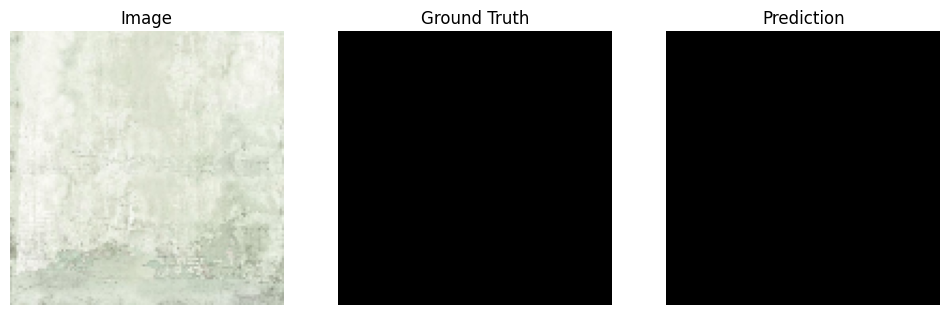

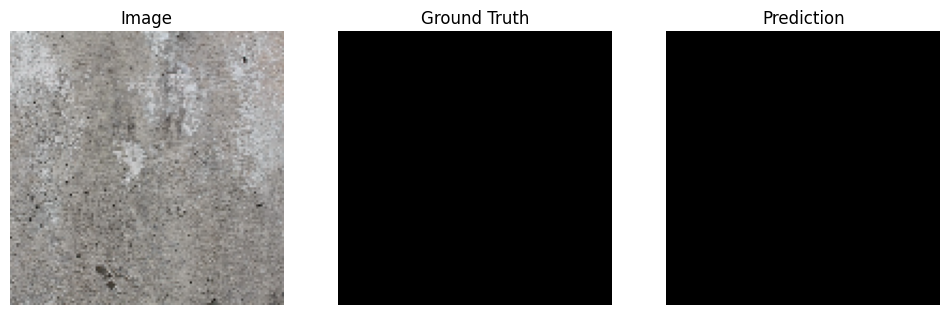

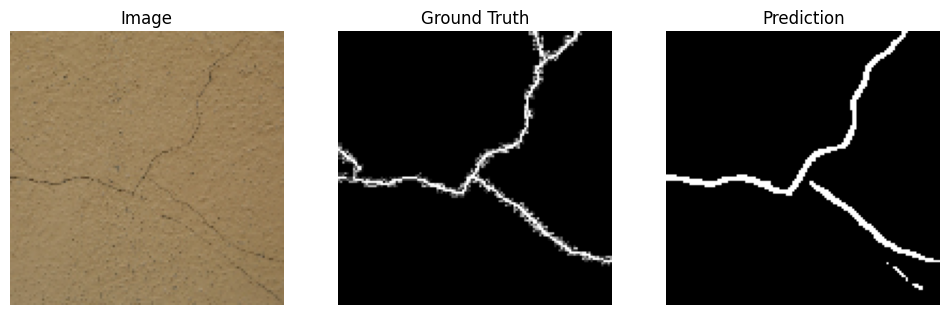

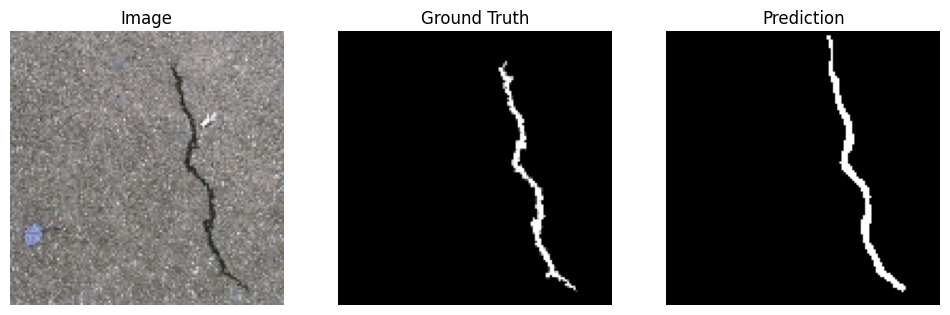

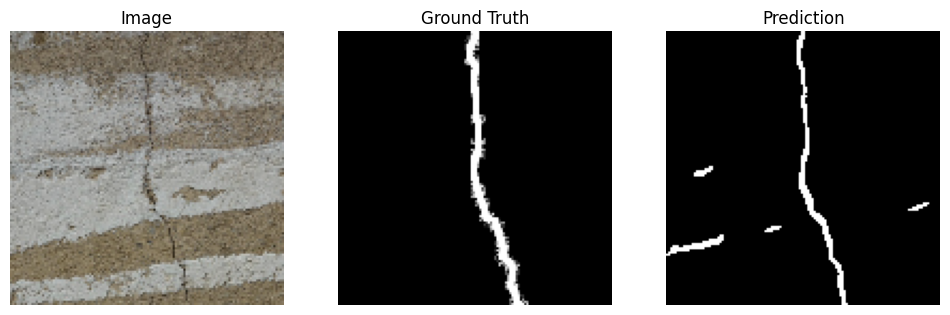

In [ ]:
def visualize_prediction(idx):
    img = X_val[idx]
    true_mask = y_val[idx].squeeze()
    pred_mask = y_val_pred[idx].squeeze()

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask > 0.5, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

# Usa algumas imagens para validação da predição
for i in range(20):
    visualize_prediction(i)

##Salvando modelo

In [ ]:
!mkdir -p saved_model
model.save('saved_model/model_cracks.keras')

##Teste com imagens fora do dataset

In [ ]:
from PIL import Image
def load_image(img_path):
  IMG_PATH = img_path
  IMG_SIZE = (128, 128)


  image = Image.open(IMG_PATH).resize(IMG_SIZE)
  image_np = np.array(image).astype("float32") / 255.0
  if image_np.ndim == 2:  # grayscale
     image_np = np.expand_dims(image_np, axis=-1)
  input_tensor = np.expand_dims(image_np, axis=0)  # shape: (1, H, W, C)
  return input_tensor, image_np


#predição e plot da máscara binária
def predict_mask(model, img_tensor, image_np):
  pred = model.predict(img_tensor)
  pred_mask = (pred[0] > 0.5).astype(np.uint8)

#display
  plt.figure(figsize=(10, 5))
  plt.subplot(1, 2, 1)
  plt.title("Input Image")
  plt.imshow(image_np.squeeze(), cmap='gray' if image_np.shape[-1] == 1 else None)
  plt.axis("off")

  plt.subplot(1, 2, 2)
  plt.title("Prediction")
  plt.imshow(pred_mask.squeeze(), cmap='gray')
  plt.axis("off")
  plt.show()

#Imagem sem cracks
#img_tensor, image_np = load_image('wall.jpg')
#predict_mask(model, img_tensor, image_np)


#Imagem com cracks óbvios
#img_tensor, image_np = load_image('cracks.jpeg')
#predict_mask(model, img_tensor, image_np)

#Imagem com tijolos para testas capacidade de discernimento entre
#Lacunas de tijolos e rachaduras
#img_tensor, image_np = load_image('bricks.jpg')
#predict_mask(model, img_tensor, image_np)

#Underwater pipe
#img_tensor, image_np = load_image('damaged_pipe.jpg')
#predict_mask(model, img_tensor, image_np)

#img_tensor, image_np = load_image('gray_wall.jpg')
#predict_mask(model, img_tensor, image_np)

#img_tensor, image_np = load_image('metalscratch.jpg')
#predict_mask(model, img_tensor, image_np)

#img_tensor, image_np = load_image('coppercrack.jpg')
#predict_mask(model, img_tensor, image_np)

#img_tensor, image_np = load_image('picrack.jpg')
#predict_mask(model, img_tensor, image_np)